In [ ]:
# rutas del proyecto (ver modules/paths.py)
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from modules.paths import RAW, PROC, OUT


# INS: posicion relativa vs absoluta

Grafica `ins_data_prueba_50_abs.csv`:
- **pos_x vs pos_y**: posicion relativa del INS (por segmento).
- **abs_x vs abs_y**: posicion absoluta reconstruida (acumulada a lo largo de los segmentos).

El archivo trae las versiones en metros `abs_x_m / abs_y_m` (= `abs_* / 1000`).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV = PROC / "2026-08-18/ins_data_prueba_50_abs.csv"
POS_SCALE = 1000.0   # pos_* en mm -> metros (igual que abs_x_m = abs_x/1000)

df = pd.read_csv(CSV, parse_dates=['date'])
df['t'] = (df['date'] - df['date'].iloc[0]).dt.total_seconds()

# pos en metros
df['pos_x_m'] = df['pos_x'] / POS_SCALE
df['pos_y_m'] = df['pos_y'] / POS_SCALE

print(f"{len(df)} filas | ref_id={sorted(df['ref_id'].unique())} | segmentos={df['segment'].nunique()} | dur={df['t'].iloc[-1]:.0f}s")
df.head()

13302 filas | ref_id=[np.int64(11), np.int64(12), np.int64(13)] | segmentos=33 | dur=1477s


,date,ref_id,pos_x,pos_y,pos_z,yaw,segment,abs_x,abs_y,abs_z,abs_x_m,abs_y_m,abs_z_m,yaw_deg,step_mm,t,pos_x_m,pos_y_m
0,2026-08-18 20:02:31,13,-33069,1719,-9884,-1285,1,-33069,1719,-9884,-33.069,1.719,-9.884,-12.85,0.0,0.0,-33.069,1.719
1,2026-08-18 20:02:31,13,-33069,1719,-9884,-1284,1,-33069,1719,-9884,-33.069,1.719,-9.884,-12.84,0.0,0.0,-33.069,1.719
2,2026-08-18 20:02:31,13,-33069,1719,-9884,-1283,1,-33069,1719,-9884,-33.069,1.719,-9.884,-12.83,0.0,0.0,-33.069,1.719
3,2026-08-18 20:02:31,13,-33069,1719,-9884,-1282,1,-33069,1719,-9884,-33.069,1.719,-9.884,-12.82,0.0,0.0,-33.069,1.719
4,2026-08-18 20:02:31,13,-33069,1719,-9884,-1279,1,-33069,1719,-9884,-33.069,1.719,-9.884,-12.79,0.0,0.0,-33.069,1.719


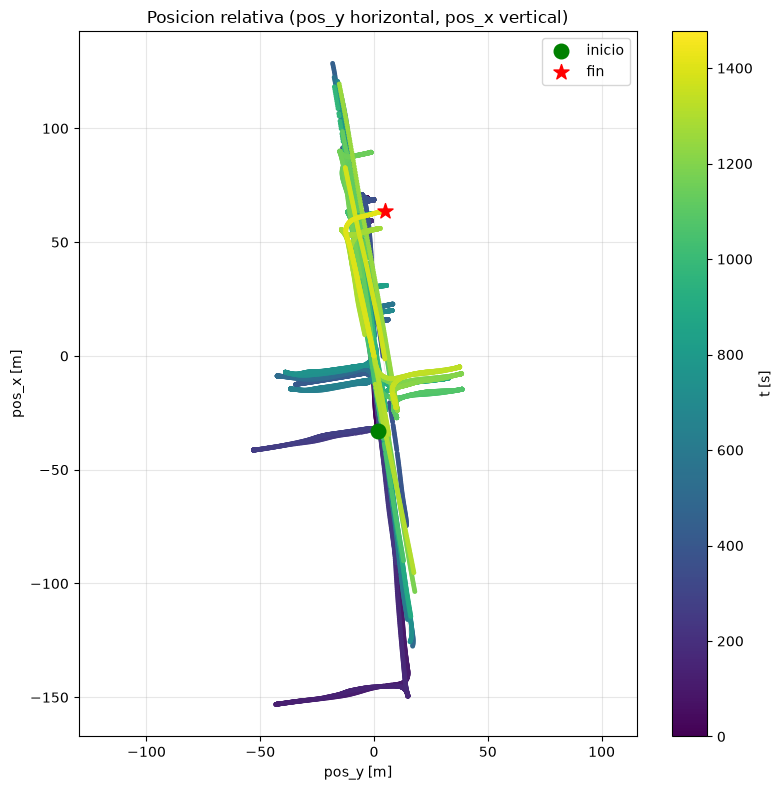

In [6]:
# pos: eje horizontal = pos_y (positivo derecha), eje vertical = pos_x (positivo arriba)
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(df['pos_y_m'], df['pos_x_m'], c=df['t'], cmap='viridis', s=6, zorder=2)
ax.plot(df['pos_y_m'], df['pos_x_m'], lw=0.3, color='gray', alpha=0.4, zorder=1)
ax.scatter(df['pos_y_m'].iloc[0],  df['pos_x_m'].iloc[0],  color='green', s=110, marker='o', zorder=3, label='inicio')
ax.scatter(df['pos_y_m'].iloc[-1], df['pos_x_m'].iloc[-1], color='red',   s=130, marker='*', zorder=3, label='fin')
ax.set_xlabel('pos_y [m]'); ax.set_ylabel('pos_x [m]')
ax.set_title('Posicion relativa (pos_y horizontal, pos_x vertical)')
ax.set_aspect('equal', adjustable='datalim'); ax.grid(alpha=0.3); ax.legend()
fig.colorbar(sc, ax=ax, label='t [s]')
plt.tight_layout(); plt.show()

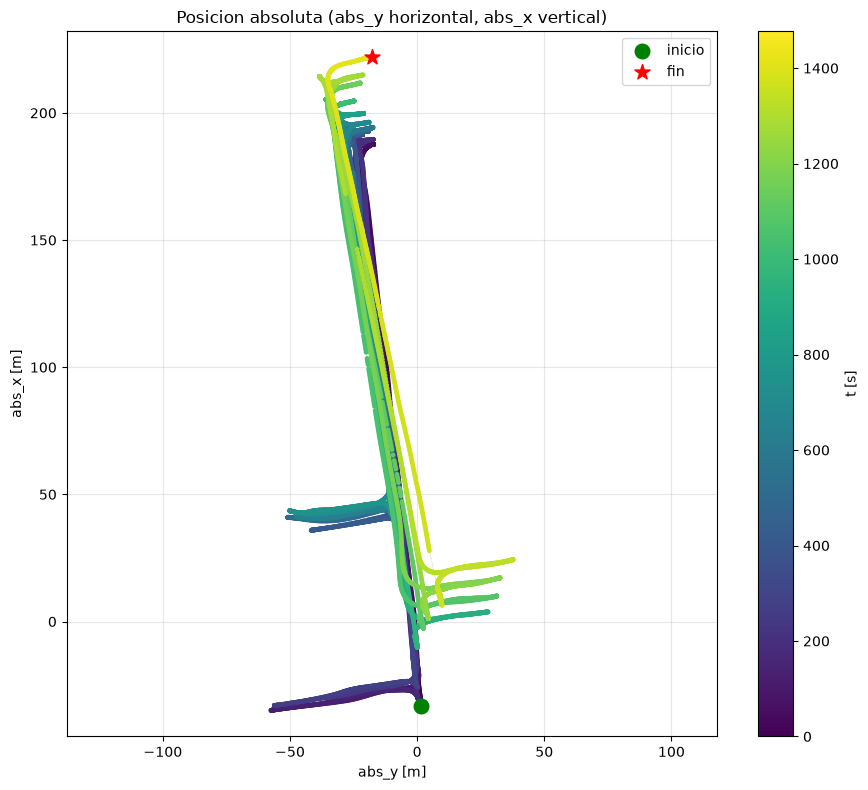

In [7]:
# abs: eje horizontal = abs_y (positivo derecha), eje vertical = abs_x (positivo arriba)
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(df['abs_y_m'], df['abs_x_m'], c=df['t'], cmap='viridis', s=6, zorder=2)
ax.plot(df['abs_y_m'], df['abs_x_m'], lw=0.3, color='gray', alpha=0.4, zorder=1)
ax.scatter(df['abs_y_m'].iloc[0],  df['abs_x_m'].iloc[0],  color='green', s=110, marker='o', zorder=3, label='inicio')
ax.scatter(df['abs_y_m'].iloc[-1], df['abs_x_m'].iloc[-1], color='red',   s=130, marker='*', zorder=3, label='fin')
ax.set_xlabel('abs_y [m]'); ax.set_ylabel('abs_x [m]')
ax.set_title('Posicion absoluta (abs_y horizontal, abs_x vertical)')
ax.set_aspect('equal', adjustable='datalim'); ax.grid(alpha=0.3); ax.legend()
fig.colorbar(sc, ax=ax, label='t [s]')
plt.tight_layout(); plt.show()

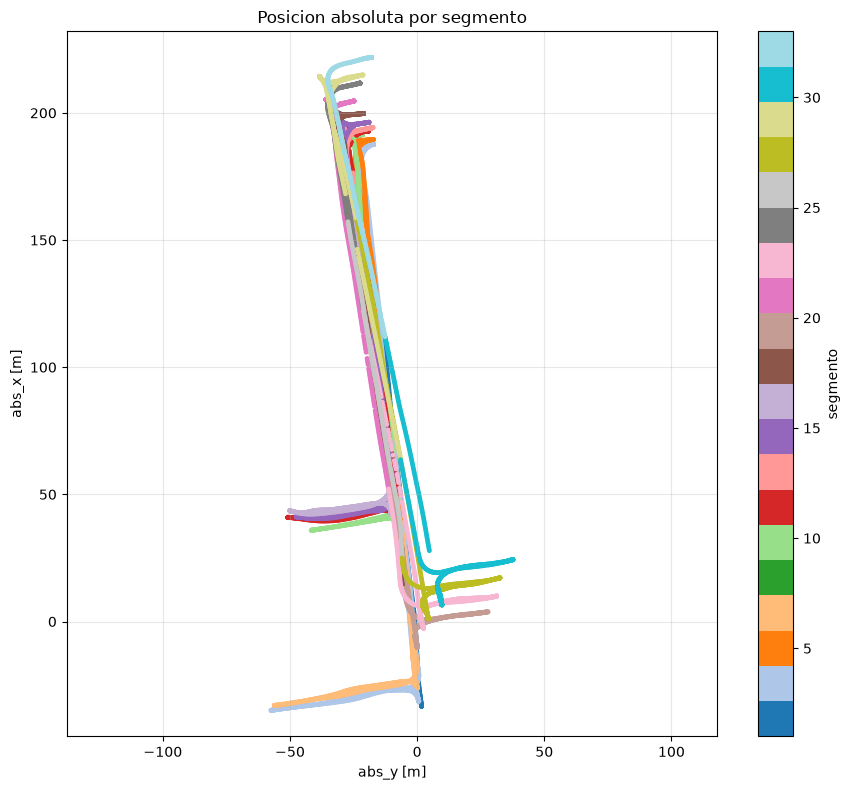

In [8]:
# abs por segmento: eje horizontal = abs_y (positivo derecha), eje vertical = abs_x (positivo arriba)
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(df['abs_y_m'], df['abs_x_m'], c=df['segment'], cmap='tab20', s=6)
ax.set_xlabel('abs_y [m]'); ax.set_ylabel('abs_x [m]')
ax.set_title('Posicion absoluta por segmento')
ax.set_aspect('equal', adjustable='datalim'); ax.grid(alpha=0.3)
fig.colorbar(sc, ax=ax, label='segmento')
plt.tight_layout(); plt.show()